In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [3]:
from langchain_groq import ChatGroq

model="deepseek-r1-distill-llama-70b"

#model="meta-llama/llama-4-scout-17b-16e-instruct"

In [4]:
llm=ChatGroq(model_name=model)
print(llm.invoke("hi").content)

<think>

</think>

Hello! How can I assist you today? 😊


In [5]:
import operator
from typing import List
from langgraph.graph.message import add_messages
from pydantic import BaseModel , Field
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph,MessagesState,START,END
from langgraph.prebuilt import ToolNode

In [6]:
#In Langgraph we can configure the memory
#check in LANGGRAPH git hub for all type of message state or etc

from typing import TypedDict, List, Sequence, Annotated

def call_model(state:MessagesState):
    messages=state['messages'] # will give you the latest message
    #question=HumanMessage[question]
    response=llm.invoke(messages)
    return {"messages":[response]}

In [7]:

#just for checks
#HumanMessage(["Hi how r u"])

In [8]:
state={"messages":["USA population"]}

call_model(state)

{'messages': [AIMessage(content='<think>\n\n</think>\n\nAs of the most recent estimates, the population of the United States is approximately **334 million** (as of 2023). This figure is based on data from the United States Census Bureau and other demographic sources. The U.S. population grows steadily due to factors such as births, deaths, and immigration. For the most accurate and up-to-date information, you can visit the [U.S. Census Bureau website](https://www.census.gov/).', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 97, 'prompt_tokens': 5, 'total_tokens': 102, 'completion_time': 0.357662864, 'prompt_time': 0.000100878, 'queue_time': 0.203849568, 'total_time': 0.357763742}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run--460e316d-b9be-469c-ad8b-5fdc2195b50e-0', usage_metadata={'input_tokens': 5, 'output_tokens': 97, 'total_tokens': 102})]}

In [9]:
workflow=StateGraph(MessagesState)

In [10]:
workflow.add_node("my_bot",call_model)

In [11]:
workflow.add_edge(START,"my_bot")
workflow.add_edge("my_bot",END)

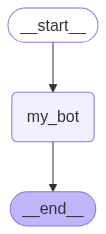

In [12]:
from IPython.display import display,Image
app=workflow.compile()

display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
input={"messages":["hi hello how are you?"]}

In [14]:
app.invoke(input)

{'messages': [HumanMessage(content='hi hello how are you?', additional_kwargs={}, response_metadata={}, id='339a3c41-86df-4aa3-b515-5d26ebd1d1a6'),
  AIMessage(content="<think>\n\n</think>\n\nHello! I'm just a virtual assistant, so I don't have feelings, but I'm here and ready to help you with whatever you need. How are *you* doing? 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 9, 'total_tokens': 53, 'completion_time': 0.184364342, 'prompt_time': 0.000188077, 'queue_time': 0.208668086, 'total_time': 0.184552419}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run--f012a6fb-9aff-477b-b56a-03a07011eedd-0', usage_metadata={'input_tokens': 9, 'output_tokens': 44, 'total_tokens': 53})]}

In [15]:
for output in app.stream(input):
    for key,value in output.items():
        print(f"Output from {key} Node")
        print("_______")
        print(value)
        print("\n")

Output from my_bot Node
_______
{'messages': [AIMessage(content="<think>\n\n</think>\n\nHello! I'm just a virtual assistant, so I don't have feelings, but I'm here and ready to help you with whatever you need. How are *you* doing? 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 9, 'total_tokens': 53, 'completion_time': 0.185253201, 'prompt_time': 0.000204757, 'queue_time': 0.205061788, 'total_time': 0.185457958}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run--f994dba0-3299-4477-b79d-91ff6539987d-0', usage_metadata={'input_tokens': 9, 'output_tokens': 44, 'total_tokens': 53})]}




In [16]:
@tool
def search(query:str):
    """this is a cutom tool for weather"""
    if "trichy" in query.lower():
        return"the temp is 45* celsius Arun it is from tool"
    else:
        return"the temp is 25* and cloudy it is from tool"

In [17]:
search.invoke("Trichy temp")
search

StructuredTool(name='search', description='this is a cutom tool for weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x107f6d4e0>)

In [18]:
#can check what are all the parameters it si getting
search
tools=[search]

In [19]:
#LLM has bind tool which take all the list of tools
llm_with_tool=llm.bind_tools(tools)

In [20]:
response=llm_with_tool.invoke("what ias the weather in trichy")

In [21]:
response.tool_calls

[{'name': 'search',
  'args': {'query': 'weather in Trichy'},
  'id': '28dd9kktw',
  'type': 'tool_call'}]

In [22]:
response.content

''

In [23]:
llm_with_tool.invoke("what is the weather in Trichy")

#llm_with_tool.invoke("hi how are you?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'fd7nctt8c', 'function': {'arguments': '{"query":"weather in Trichy"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 201, 'prompt_tokens': 132, 'total_tokens': 333, 'completion_time': 0.73516138, 'prompt_time': 0.008447566, 'queue_time': 0.204703519, 'total_time': 0.743608946}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--e578aa37-7c81-48e5-a92c-ef2aa374d964-0', tool_calls=[{'name': 'search', 'args': {'query': 'weather in Trichy'}, 'id': 'fd7nctt8c', 'type': 'tool_call'}], usage_metadata={'input_tokens': 132, 'output_tokens': 201, 'total_tokens': 333})

In [24]:
def call_model(state:MessagesState):
    question=state["messages"] # will give you the latest message
    #question=HumanMessage[question]
    response=llm_with_tool.invoke(question)
    return {"messages":[response]}

In [25]:
response=call_model({"messages":["what is the weather in Trichy"]})
# response["messages"][-1].content   # empty string so we need to use tool_calls
response["messages"][-1].tool_calls


[]

Now we need to Orchestrate the model and tool , we need to redirect it to the llm, so we need router
Information of the tool is in AI Message

In [26]:
def router_function(state:MessagesState):
    message=state["messages"]
    last_message=state["messages"][-1]
    if (last_message.tool_calls):
        return "tools"
    
router_function(response)

In [27]:
tools

[StructuredTool(name='search', description='this is a cutom tool for weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x107f6d4e0>)]

In [28]:
tool_node=ToolNode(tools)
tool_node

tools(tags=None, recurse=True, explode_args=False, func_accepts_config=True, func_accepts={'store': ('__pregel_store', None)}, tools_by_name={'search': StructuredTool(name='search', description='this is a cutom tool for weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x107f6d4e0>)}, tool_to_state_args={'search': {}}, tool_to_store_arg={'search': None}, handle_tool_errors=True, messages_key='messages')

In [29]:
workflow2=StateGraph(MessagesState)

#this is a inbuilt package tool
workflow2.add_node("mytools",tool_node)

#This is defined by us
workflow2.add_node("llmwithtool",call_model)

workflow2.add_edge(START,"llmwithtool")


#if the router function returns tool it will route to tool as below, tools should match the retun in router function call
workflow2.add_conditional_edges("llmwithtool",router_function,{"tools":"mytools",END:END})

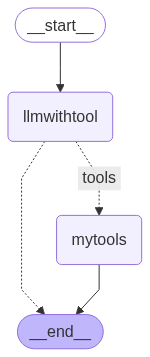

In [30]:
app2=workflow2.compile()
display(Image(app2.get_graph().draw_mermaid_png()))

#if I am asking anything related to tool it will move to tool, LLM will decide wether we need to call tool or not

In [31]:
#calling LLM automatically can see the diff in answer
app2.invoke({"messages":["what is the weather in Singapore"]})

#If you need to take the final answer

result=app2.invoke({"messages":["what is the weather in Singapore"]})
result["messages"][-1].content

KeyError: None

In [113]:
#app2.invoke({"messages":["hi"]})

In [114]:
#calling tool automatically can see the diff in answer
app2.invoke({"messages":["what is the weather in Singapore"]})

{'messages': [HumanMessage(content='what is the weather in Singapore', additional_kwargs={}, response_metadata={}, id='efb33795-6702-452c-bdb6-d4c13780ca29'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'qjb5ngcx1', 'function': {'arguments': '{"query":"Singapore"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 193, 'prompt_tokens': 130, 'total_tokens': 323, 'completion_time': 0.832494697, 'prompt_time': 0.008951366, 'queue_time': 0.20463398600000002, 'total_time': 0.841446063}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--b04f5c4e-7a7f-4b0f-a9bd-c80c6570763a-0', tool_calls=[{'name': 'search', 'args': {'query': 'Singapore'}, 'id': 'qjb5ngcx1', 'type': 'tool_call'}], usage_metadata={'input_tokens': 130, 'output_tokens': 193, 'total_tokens': 323}),
  ToolMessage(content='the temp is 25* and cloudy it is from tool', na

in our Workflow we can have EDGE,COnditional EDGES,Loop

In [115]:
workflow2.add_edge("mytools","llmwithtool")

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


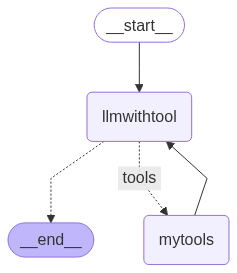

In [116]:
app3=workflow2.compile()
display(Image(app3.get_graph().draw_mermaid_png()))

#here from tool it is been looped to LLM

In [118]:
#Stream will give output in multiple batches    , Key has the node name, and value has the actuall data
for output in app3.stream({"messages":["what is the weather in Trichy and tell me some good hotels"]}):
    for key,value in output.items():
        print(f"here is the key {key}")
        print("-----")
        print(f"{value}")
        print("\n")


here is the key llmwithtool
-----
{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6gchgckdq', 'function': {'arguments': '{"query":"Trichy weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 348, 'prompt_tokens': 138, 'total_tokens': 486, 'completion_time': 1.475912989, 'prompt_time': 0.00877944, 'queue_time': 0.05323558, 'total_time': 1.4846924289999999}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--08c65b8f-f6ff-4297-bbc1-30935eed8b4e-0', tool_calls=[{'name': 'search', 'args': {'query': 'Trichy weather'}, 'id': '6gchgckdq', 'type': 'tool_call'}], usage_metadata={'input_tokens': 138, 'output_tokens': 348, 'total_tokens': 486})]}


here is the key mytools
-----
{'messages': [ToolMessage(content='the temp is 45* celsius Arun it is from tool', name='search', id='f2e772ad-851e-4441-b1b6-5c7268544d31', too

KeyError: None

In [37]:
#what is the weather in Trichy and tell me some good hotels

#here we can connect various tools weather,trip.com for booking and etc

In [119]:
#For the memory Management and how it is appended
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

In [120]:
workflow3=StateGraph(MessagesState)

#this is a inbuilt package tool
workflow3.add_node("mytools",tool_node)

#This is defined by us
workflow3.add_node("llm_with_the_tool",call_model)

workflow3.add_edge(START,"llm_with_the_tool")
workflow3.add_edge("mytools","llm_with_the_tool")

#if the router function returns tool it will route to tool as below, tools should match the retun in router function call
workflow3.add_conditional_edges("llm_with_the_tool",router_function,{"tools":"mytools",END:END})

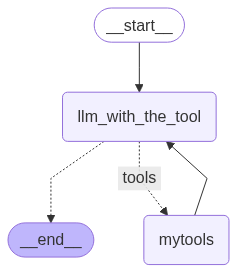

In [121]:
app4=workflow3.compile(checkpointer=memory)  #need to pass the memeory here

display(Image(app4.get_graph().draw_mermaid_png()))

#here from tool it is been looped to LLM

In [122]:
#FOr every Chat new Thread ID is been assigned
# need to pass it when we invoke/stream the Output
#config={"configuration":{"thread_id":"2"}}

import uuid
#used uuid to generate unique ID randomly
config = {
    "configurable": {
        "thread_id": str(uuid.uuid4())  # generates a random unique ID
    }
}

In [124]:
#Stream will give output in multiple batches    , Key has the node name, and value has the actuall data
#Stream is going to load all our output in the memory and in batches it is going to process that
for output in app4.stream(
    {"messages":["what is the weather in Trichy and tell me some good hotels"]},config=config,stream_mode="values"):
    for key,value in output.items():
        print(f"here is the key {key}")
        print("-----")
        print(f"{value}")
        print("\n")


here is the key messages
-----
[HumanMessage(content='what is the weather in Trichy and tell me some good hotels', additional_kwargs={}, response_metadata={}, id='b5808770-61c8-440f-8914-524e4ef5fcd0'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '977ntfvfv', 'function': {'arguments': '{"query":"Trichy weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 262, 'prompt_tokens': 138, 'total_tokens': 400, 'completion_time': 1.217168949, 'prompt_time': 0.00877958, 'queue_time': 0.05840277, 'total_time': 1.225948529}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--6928d23b-9222-4131-bdd1-ea79979240f4-0', tool_calls=[{'name': 'search', 'args': {'query': 'Trichy weather'}, 'id': '977ntfvfv', 'type': 'tool_call'}], usage_metadata={'input_tokens': 138, 'output_tokens': 262, 'total_tokens': 400}), ToolMessage(content='the tem

KeyError: None

In [178]:
events=app4.stream(
    {"messages":["tell me about USA"]},config=config,stream_mode="values"
)

In [180]:
for event in events:
 event["messages"][-1].pretty_print()

In [129]:
#NO need to capture all, just capture last 5 messgaes

memory.get(config)


{'v': 3,
 'ts': '2025-06-19T14:36:33.875868+00:00',
 'id': '1f04d1ac-c315-6468-801c-552bc6b2ad73',
 'channel_versions': {'__start__': '00000000000000000000000000000012.0.7295615640394982',
  'messages': '00000000000000000000000000000030.0.8699307956740486',
  'branch:to:llm_with_the_tool': '00000000000000000000000000000030.0.8016240126789813',
  'branch:to:mytools': '00000000000000000000000000000030.0.07956708239617072'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000011.0.7692226496987005'},
  'llm_with_the_tool': {'branch:to:llm_with_the_tool': '00000000000000000000000000000028.0.6887808288927131'},
  'mytools': {'branch:to:mytools': '00000000000000000000000000000029.0.329220585766859'}},
 'channel_values': {'messages': [HumanMessage(content='what is the weather in Trichy and tell me some good hotels', additional_kwargs={}, response_metadata={}, id='b5808770-61c8-440f-8914-524e4ef5fcd0'),
   AIMessage(content='', additional_kwargs={'to

In [181]:
check=memory.get(config)
print(len(check))
print("www",check["channel_values"]["messages"][-1])
for i in (0,-6):
    print(check["channel_values"]["messages"][i])

7
www content='the temp is 25* and cloudy it is from tool' name='search' id='9e89dd9c-816e-433f-ba5c-df1235aa5f30' tool_call_id='a3nxhrp4m'
content='what is the weather in Trichy and tell me some good hotels' additional_kwargs={} response_metadata={} id='b5808770-61c8-440f-8914-524e4ef5fcd0'
content='the temp is 45* celsius Arun it is from tool' name='search' id='e4dcdb5e-abb1-4166-93c8-86d0bf888ce5' tool_call_id='gwmz2sj2w'


In [1]:
from langchain.schema import HumanMessage, AIMessage

# Assume `chat_history` is your full message list (like the one you posted)
chat_history = [...]  # your list of messages

for msg in check:
    if isinstance(msg, HumanMessage):
        print(f"🧑 HumanMessage: {msg.content}")
    
    elif isinstance(msg, AIMessage):
        print(f"🤖 AIMessage: {msg.content}")
        if "tool_calls" in msg.additional_kwargs:
            for tool_call in msg.additional_kwargs["tool_calls"]:
                query_args = tool_call["function"]["arguments"]
                print(f"🔧 Tool call query args: {query_args}")



NameError: name 'check' is not defined